In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [2]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/'

In [3]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']
#taux_files, taux_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-2],file_end='nc')
#tauy_files, tauy_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[-1],file_end='nc')

#tauxy = xr.open_mfdataset(taux_filepaths+tauy_filepaths)#.where(np.isfinite(land_mask))
#taux_masked = tauxy['oceTAUX'][:,:-1,:-1].where(np.isfinite(land_mask))

In [4]:
ridge_points = xr.open_dataset(cutout_path+'ridge_points_repelling_bad.nc')

In [8]:
ridge_points.where(ridge_points.isel(lon_lat=1)>40.3)

<xarray.Dataset>
Dimensions:                (time: 1519, points: 8784, lon_lat: 2)
Coordinates:
  * points                 (points) int64 0 1 2 3 4 ... 8779 8780 8781 8782 8783
  * lon_lat                (lon_lat) object 'lon' 'lat'
  * time                   (time) datetime64[ns] 2011-11-01 ... 2012-11-14T12...
Data variables:
    attracting_structures  (time, points, lon_lat) float64 nan nan ... nan nan
    repelling_structures   (time, points, lon_lat) float64 nan nan ... nan nan

In [5]:
ridge_counts_attracting = []
ridge_counts_repelling = []
for i in range(0,len(ridge_points.time)):
    lon_points_attr = ridge_points.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
    #lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
    ridge_counts_attracting.append(len(lon_points_attr))
    ridge_counts_repelling.append(len(lon_points_rep))
    #lat_points_rep = ridge_points.isel(time=i,lon_lat=1)['repelling_structures']

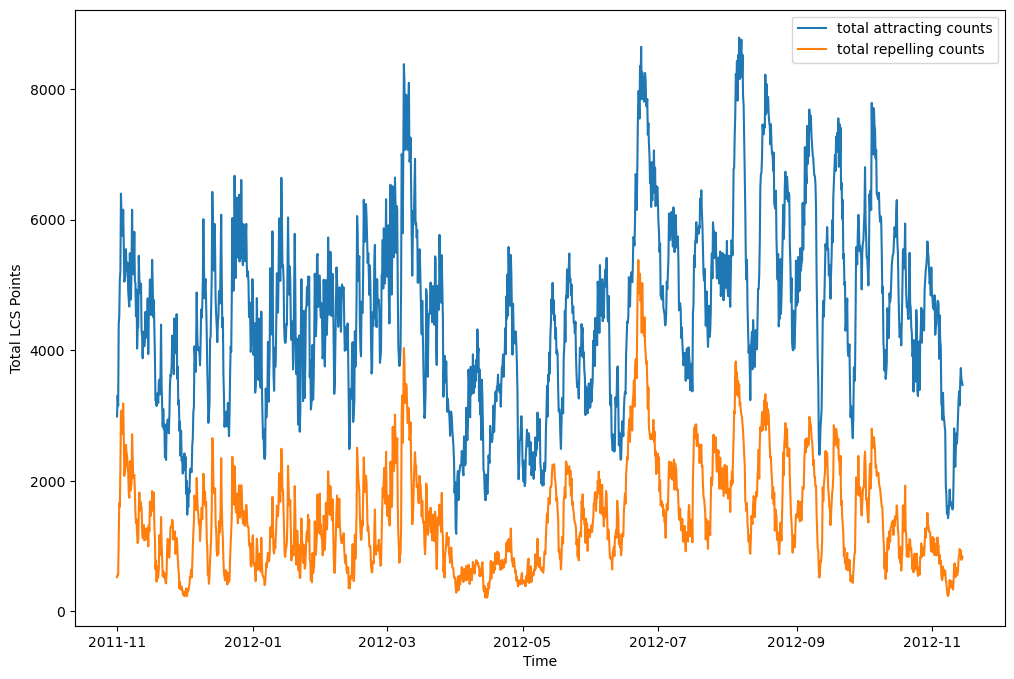

In [9]:
plt.figure(figsize=(12,8))
plt.plot(ridge_points.time,ridge_counts_attracting,label='total attracting counts')
plt.plot(ridge_points.time,ridge_counts_repelling,label='total repelling counts')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Total LCS Points')
plt.savefig('./counts_of_LCS.png')

In [11]:
lcs_model = xr.open_dataset('/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [31]:
lcs_model_area_N = lcs_model.where(lcs_model.lat>40.7)
lcs_model_area_C = lcs_model.where(np.logical_and(lcs_model.lat<40.7,lcs_model.lat>40))
lcs_model_area_S = lcs_model.where(lcs_model.lat<40)

In [50]:
Area_norm_total = np.array(np.isfinite(lcs_model['ALCS'].isel(time=0)).sum())
Area_norm_N = np.array(np.isfinite(lcs_model_area_N['ALCS'].isel(time=0)).sum())
Area_norm_C = np.array(np.isfinite(lcs_model_area_C['ALCS'].isel(time=0)).sum())
Area_norm_S = np.array(np.isfinite(lcs_model_area_S['ALCS'].isel(time=0)).sum())

array(40873)

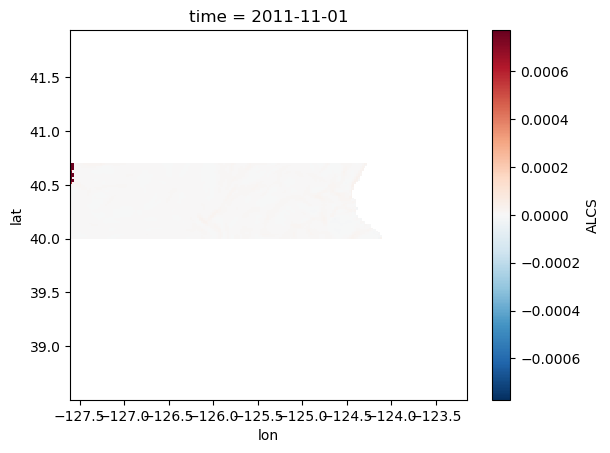

In [33]:
plt.close()
lcs_model_area_C.isel(time=0)['ALCS'].plot()

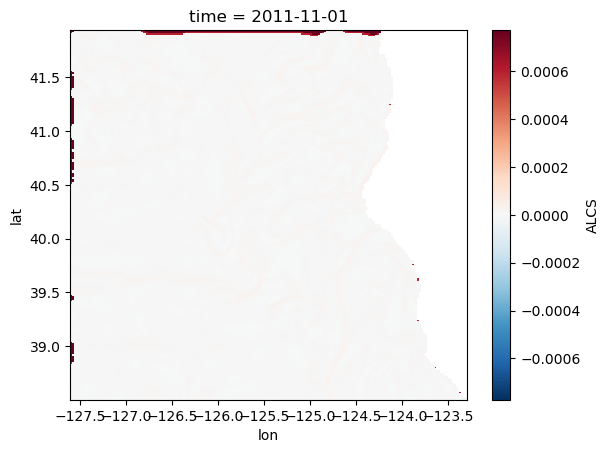

In [17]:
lcs_model_area['ALCS']

In [38]:
ridge_points_N = ridge_points.where(ridge_points.isel(lon_lat=1)>40.7)
ridge_points_C = ridge_points.where(np.logical_and(ridge_points.isel(lon_lat=1)>40,ridge_points.isel(lon_lat=1)<40.7))
ridge_points_S = ridge_points.where(ridge_points.isel(lon_lat=1)<40)

In [39]:
ridge_counts_attracting_N = []
ridge_counts_repelling_N = []
for i in range(0,len(ridge_points.time)):
    lon_points_attr = ridge_points_N.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
    #lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points_N.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
    ridge_counts_attracting_N.append(len(lon_points_attr))
    ridge_counts_repelling_N.append(len(lon_points_rep))

In [40]:
ridge_counts_attracting_C = []
ridge_counts_repelling_C = []
for i in range(0,len(ridge_points.time)):
    lon_points_attr = ridge_points_C.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
    #lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points_C.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
    ridge_counts_attracting_C.append(len(lon_points_attr))
    ridge_counts_repelling_C.append(len(lon_points_rep))

In [41]:
ridge_counts_attracting_S = []
ridge_counts_repelling_S = []
for i in range(0,len(ridge_points.time)):
    lon_points_attr = ridge_points_S.isel(time=i,lon_lat=0)['attracting_structures'].dropna('points',how='all')
    #lat_points_attr = ridge_points.isel(time=i,lon_lat=1)['attracting_structures']
    lon_points_rep = ridge_points_S.isel(time=i,lon_lat=0)['repelling_structures'].dropna('points',how='all')
    ridge_counts_attracting_S.append(len(lon_points_attr))
    ridge_counts_repelling_S.append(len(lon_points_rep))

Text(0, 0.5, 'normalized total LCS Points')

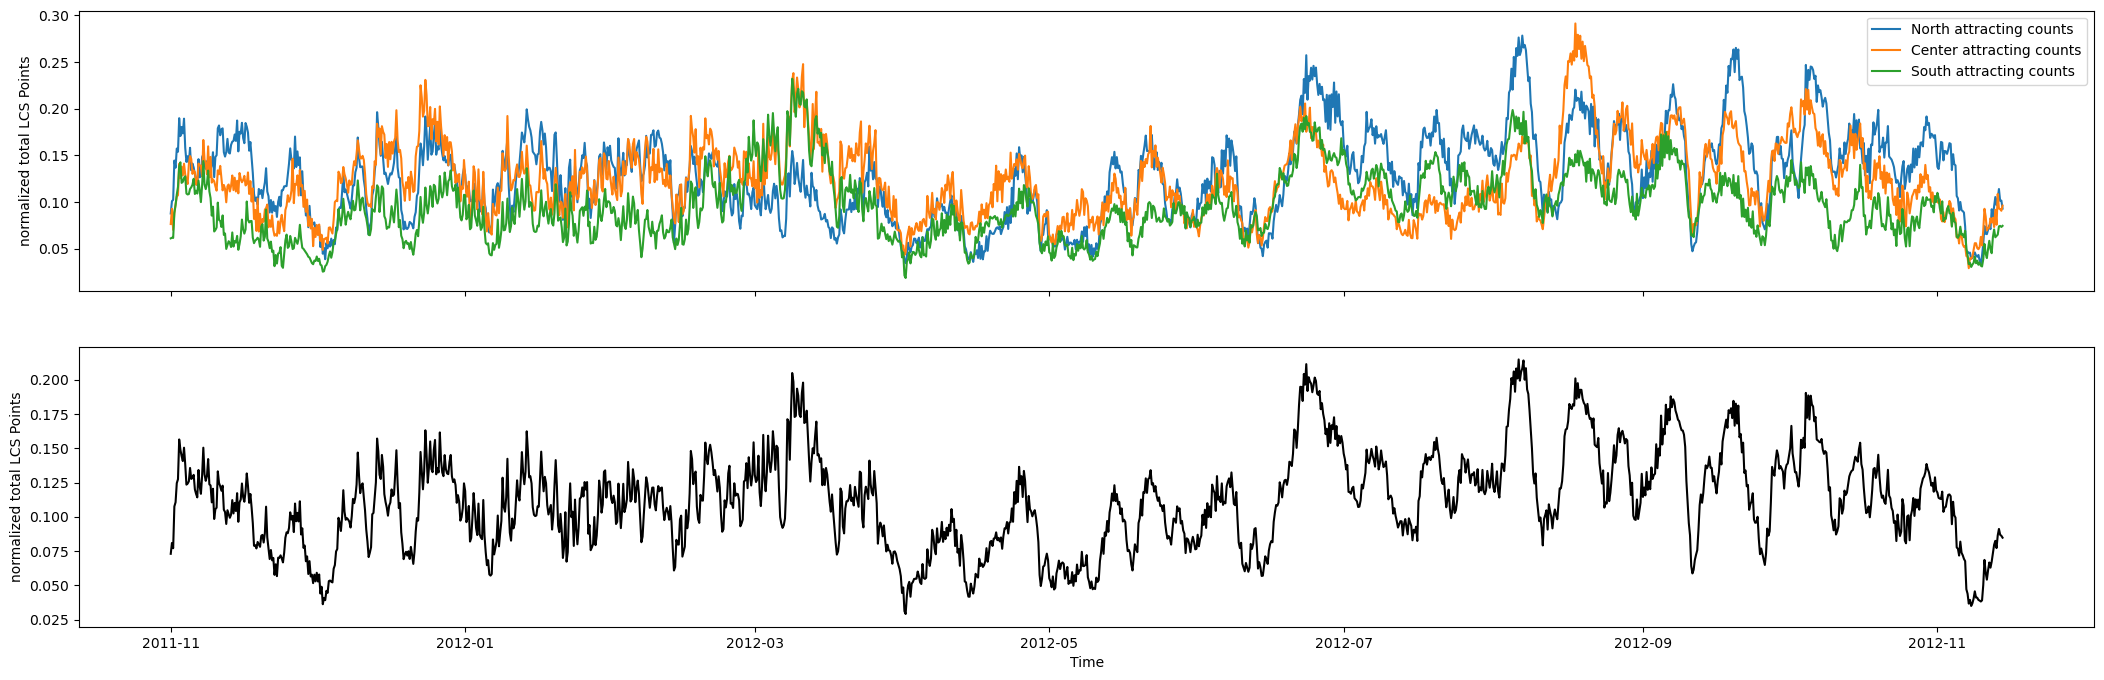

In [62]:
fig,ax = plt.subplots(ncols=1, nrows=3,figsize=(26,8),sharex=True)

#plt.figure(figsize=(26,8))
ax[0].plot(ridge_points.time,ridge_counts_attracting_N/Area_norm_N,label='North attracting counts')
ax[0].plot(ridge_points.time,ridge_counts_attracting_C/Area_norm_C,label='Center attracting counts')
ax[0].plot(ridge_points.time,ridge_counts_attracting_S/Area_norm_S,label='South attracting counts')
ax[1].plot(ridge_points.time,ridge_counts_attracting/Area_norm_total,label='total attracting counts',color='black')
taux_masked.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='cumulative sum',ax=ax[2])
ax[2].set_ylabel('surface wind stress N/m$^2$')
#plt.plot(ridge_points.time,ridge_counts_repelling_N,label='N repelling counts')
ax[0].legend()
plt.xlabel('Time')
ax[0].set_ylabel('normalized total LCS Points')
ax[1].set_ylabel('normalized total LCS Points')


In [47]:
np.array(Area_norm_N)[0]

IndexError: too many indices

### Case Study (eddy)

In [38]:
case_study_range_eddy = ['2012-07-05', '2012-08-31']
case_study_range_fil = ['2012-08-06', '2012-08-19']

cs_ridge_points=ridge_points.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

In [43]:
lon_cs_attr = cs_ridge_points.isel(lon_lat=0)['attracting_structures'].dropna('points',how='all')
lat_cs_attr = cs_ridge_points.isel(lon_lat=1)['attracting_structures'].dropna('points',how='all')
lon_cs_rep = cs_ridge_points.isel(lon_lat=0)['repelling_structures'].dropna('points',how='all')
lat_cs_rep = cs_ridge_points.isel(lon_lat=1)['repelling_structures'].dropna('points',how='all')

In [27]:
eddy_ridge_points=cs_ridge_points.where(np.logical_and(ridge_points.isel(lon_lat=1)>38.8,ridge_points.isel(lon_lat=1)<40.5))
eddy_ridge_points = eddy_ridge_points.where(np.logical_and(ridge_points.isel(lon_lat=0)>-125.5,ridge_points.isel(lon_lat=0)<-123.5))

lon_cs_attr_ed = eddy_ridge_points.isel(lon_lat=0)['attracting_structures'].dropna('points',how='all')
lat_cs_attr_ed = eddy_ridge_points.isel(lon_lat=1)['attracting_structures'].dropna('points',how='all')
lon_cs_rep_ed = eddy_ridge_points.isel(lon_lat=0)['repelling_structures'].dropna('points',how='all')
lat_cs_rep_ed = eddy_ridge_points.isel(lon_lat=1)['repelling_structures'].dropna('points',how='all')

In [43]:
#eddy_ridge_points=cs_ridge_points.where(np.logical_and(ridge_points.isel(lon_lat=1)>39,ridge_points.isel(lon_lat=1)<40.1))

for i in tqdm(range(0,len(lon_cs_rep_ed.time))):
#plt.plot(lon_cs_rep.isel(time=i),lat_cs_rep.isel(time=i),'.')
    plt.plot(lon_cs_attr_ed.isel(time=i),lat_cs_attr_ed.isel(time=i),'.',markersize=4,label='attracting points')

    plt.plot(lon_cs_rep_ed.isel(time=i),lat_cs_rep_ed.isel(time=i),'.',markersize=4,label='repelling points')
    plt.xlabel('Longitude')
    plt.legend(loc='upper right')
    plt.ylabel('Latitude')
    #plt.xticks(np.arange(-125.5, -123.8, step=0.2))
    #plt.yticks(np.arange(38.95, 40.5, step=0.30))
    plt.xlim([-125.5,-123.5])
    plt.ylim([38.8,40.5])
    plt.title(str(np.array(lon_cs_rep_ed.isel(time=i).time))[:10]+' '+str(np.array(lon_cs_rep_ed.isel(time=i).time))[11:16])
    plt.savefig('/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/eddy_points_rep_attr/eddy_'+str(i).zfill(3)+'.png')
    plt.close()

  0%|          | 0/232 [00:00<?, ?it/s]

Text(0.5, 1.0, '2012-08-31 18:00')

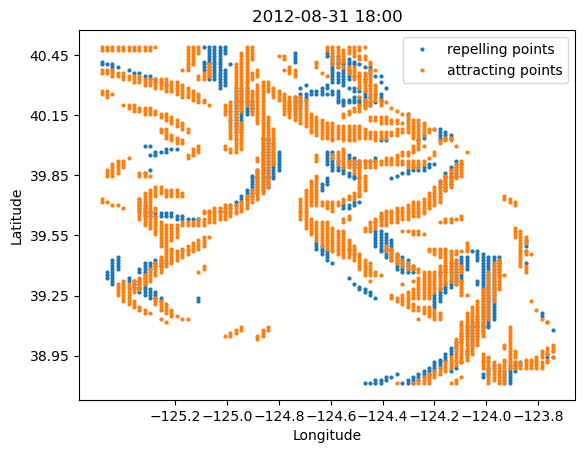

In [29]:
plt.plot(lon_cs_rep_ed.isel(time=i),lat_cs_rep_ed.isel(time=i),'.',markersize=4,label='repelling points')
plt.plot(lon_cs_attr_ed.isel(time=i),lat_cs_attr_ed.isel(time=i),'.',markersize=4,label='attracting points')
plt.xlabel('Longitude')
plt.legend(loc='upper right')
plt.ylabel('Latitude')
plt.xticks(np.arange(-125.2, -123.5, step=0.2))
plt.yticks(np.arange(38.95, 40.3, step=0.30))
plt.title(str(np.array(lon_cs_rep_ed.isel(time=i).time))[:10]+' '+str(np.array(lon_cs_rep_ed.isel(time=i).time))[11:16])

### Case Study (filament)

In [39]:
cs_ridge_points_fil=ridge_points.sel(time=slice(case_study_range_fil[0],case_study_range_fil[1]))

In [40]:
fil_ridge_points=cs_ridge_points_fil.where(np.logical_and(ridge_points.isel(lon_lat=1)>40,ridge_points.isel(lon_lat=1)<42))
fil_ridge_points = fil_ridge_points.where(np.logical_and(ridge_points.isel(lon_lat=0)>-126.9,ridge_points.isel(lon_lat=0)<-123.5))

In [41]:
lon_cs_attr_fil = fil_ridge_points.isel(lon_lat=0)['attracting_structures'].dropna('points',how='all')
lat_cs_attr_fil = fil_ridge_points.isel(lon_lat=1)['attracting_structures'].dropna('points',how='all')
lon_cs_rep_fil = fil_ridge_points.isel(lon_lat=0)['repelling_structures'].dropna('points',how='all')
lat_cs_rep_fil = fil_ridge_points.isel(lon_lat=1)['repelling_structures'].dropna('points',how='all')

In [44]:
for i in tqdm(range(0,len(lon_cs_rep_fil))):
    plt.plot(lon_cs_attr_fil.isel(time=i),lat_cs_attr_fil.isel(time=i),'.',markersize=4,label='attracting points')
    plt.plot(lon_cs_rep_fil.isel(time=i),lat_cs_rep_fil.isel(time=i),'.',markersize=4, label='repelling points')
    plt.legend(loc='upper right')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    plt.ylim([40,42])
    plt.title(str(np.array(lon_cs_rep_fil.isel(time=i).time))[:10]+' '+str(np.array(lon_cs_rep_fil.isel(time=i).time))[11:16])
    plt.xlim([-126.9,-124])
    plt.savefig('/media/drdarby/Elements/data/Thesis/LLC4320/animations/panels/Filiment_points_rep/fil_'+str(i).zfill(3)+'.png')
    plt.close()

  0%|          | 0/56 [00:00<?, ?it/s]

Text(0.5, 1.0, '2012-08-19 18:00')

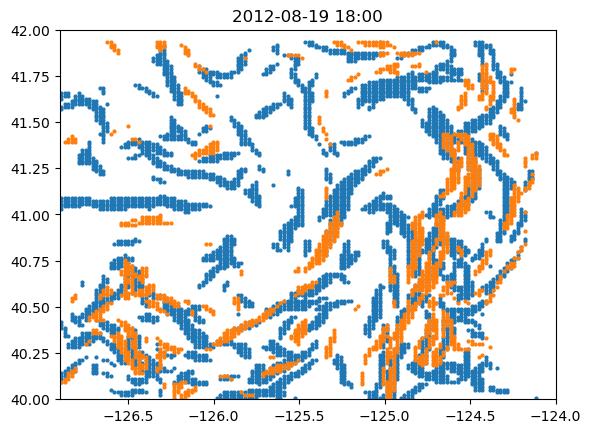

In [35]:
i=47
plt.plot(lon_cs_attr_fil.isel(time=i),lat_cs_attr_fil.isel(time=i),'.',markersize=4)

plt.plot(lon_cs_rep_fil.isel(time=47),lat_cs_rep_fil.isel(time=47),'.',markersize=4)
plt.ylim([40,42])
plt.xlim([-126.9,-124])
plt.title(str(np.array(lon_cs_rep_fil.isel(time=i).time))[:10]+' '+str(np.array(lon_cs_rep_fil.isel(time=i).time))[11:16])


In [ ]:
vort_lcs_files, vort_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'vort_lcs',file_end='nc')
div_lcs_files, div_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'div_lcs',file_end='nc')
strain_lcs_files, strain_lcs_filepaths = tools.get_data_paths_from_binary(cutout_path,'strain_lcs',file_end='nc')
vort_lcs = xr.open_mfdataset(vort_lcs_filepaths)
div_lcs = xr.open_mfdataset(div_lcs_filepaths)
strain_lcs = xr.open_mfdataset(strain_lcs_filepaths)